In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))  # Add the parent directory to the system path

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,classification_report, confusion_matrix)
from transformers import (RobertaForSequenceClassification,RobertaTokenizer,TrainingArguments,Trainer) 
from data_loader import get_datasets, TASK_A_ID2LABEL, TASK_B_ID2LABEL
DATA_DIR    = '../data/'
RESULTS_DIR = '../results/'
MODELS_DIR  = '../models/'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

c:\Users\Ashwin Nair\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB


EDOS has class imbalance — Task A is 3.12x and Task B is 5.13x (majority/minority ratio).
We compute inverse frequency weights so the model is penalised more for misclassifying rare classes.
For example if "threats" has 310 samples and "derogation" has 1590, the model gets penalised ~5x more for missing a "threats" post.

In [ ]:
def compute_class_weights(dataset, num_labels, device):
    labels = [dataset[i]['labels'] for i in range(len(dataset))] ## Get the labels from the dataset
    counts = torch.zeros(num_labels) ## Initialize a tensor to hold the counts of each class
    for l in labels: ## Loop through each label in the dataset
        counts[l]+=1
    weights=1.0 / counts
    weights=weights/weights.sum()*num_labels ## Normalize the weights so that they sum to the number of classes
    print(f'Class counts: {counts.tolist()}')
    print(f'Class weights: {[round(w, 4) for w in weights.tolist()]}')
    return weights.to(device)

In [ ]:
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights=class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): ## Override the compute_loss method to use weighted CrossEntropyLoss
        labels=inputs.pop('labels')
        outputs=model(**inputs)
        logits=outputs.logits
        loss_fn=CrossEntropyLoss(weight=self.class_weights)
        loss=loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [4]:
def compute_metrics(eval_pred): ## Compute accuracy and macro F1 after each evaluation epoch. Macro F1 is the primary metric for EDOS benchmark.
    logits, labels=eval_pred
    preds=np.argmax(logits, axis=-1)
    acc=accuracy_score(labels, preds)
    precision, recall, f1, _=precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy':  round(acc, 4),'macro_f1':  round(f1, 4),'precision': round(precision, 4),'recall':    round(recall, 4)}

In [ ]:
def train_roberta(task: str):
    print(f'\n{"="*50}')
    print(f'Training RoBERTa Baseline 1 — Task {task}')
    print(f'{"="*50}')
    train_dataset, dev_dataset, test_dataset, num_labels, id2label = get_datasets(DATA_DIR, task=task, max_length=128) ## Load the datasets for the specified task with a maximum sequence length of 128 tokens
    class_weights = compute_class_weights(train_dataset, num_labels, DEVICE) ## Compute class weights for the training dataset to handle class imbalance
    model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=num_labels,id2label=id2label,label2id={v: k for k, v in id2label.items()}) ## Load the pre-trained RoBERTa model for sequence classification with the specified number of labels and label mappings
    model.to(DEVICE)
    output_dir = os.path.join(MODELS_DIR, f'roberta_task_{task}')
    training_args = TrainingArguments( ## Set up training arguments for the HuggingFace Trainer
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_ratio=0.1,
        weight_decay=0.01,
        learning_rate=2e-5,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to='none'
    )
    trainer = WeightedTrainer( ## Use the custom WeightedTrainer to handle class imbalance during training
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Save best model
    trainer.save_model(output_dir)
    print(f'\nModel saved to {output_dir}')

    return trainer, test_dataset, id2label, num_labels

In [6]:
def evaluate_roberta(trainer, test_dataset, id2label, num_labels, task: str):
    print(f'\nEvaluating on test set - Task {task}')

    predictions = trainer.predict(test_dataset) ## Get predictions from the model on the test dataset
    preds  = np.argmax(predictions.predictions, axis=-1) ## Get the predicted class labels by taking the argmax of the logits
    labels = predictions.label_ids 

    label_names = [id2label[i] for i in range(num_labels)] ### Get the label names corresponding to the label indices
    report = classification_report(labels, preds, target_names=label_names, digits=4) ### Generate a classification report that includes precision, recall, and F1-score for each class
    print('\nClassification Report:')
    print(report)

    report_path = os.path.join(RESULTS_DIR, f'task_{task}_baseline1_results.txt') ## Define the path to save the classification report
    with open(report_path, 'w') as f:
        f.write(f'RoBERTa Baseline 1 — Task {task}\n\n')
        f.write(report)
    print(f'Report saved to {report_path}')

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'RoBERTa Baseline 1 - Task {task} Confusion Matrix', fontsize=13)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    cm_path = os.path.join(RESULTS_DIR, f'task_{task}_baseline1_confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()

    # 
    acc = accuracy_score(labels, preds) ## Compute accuracy of the predictions
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    print(f'Accuracy:  {acc}')
    print(f'Precision: {p}')
    print(f'Recall:    {r}')
    print(f'Macro F1:  {f1}')

    return {'accuracy': acc, 'precision': p, 'recall': r, 'macro_f1': f1}


Training RoBERTa Baseline 1 — Task A
Task A : Train split (14000 posts)
not sexist                                    10602 (75.7%)
sexist                                         3398 (24.3%)
Task A : Dev split (2000 posts)
not sexist                                     1514 (75.7%)
sexist                                          486 (24.3%)
Task A : Test split (4000 posts)
not sexist                                     3030 (75.8%)
sexist                                          970 (24.2%)



Datasets ready — Train: 14000 | Dev: 2000 | Test: 4000
num_labels: 2
Class counts: [10602.0, 3398.0]
Class weights: [0.4854, 1.5146]


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5150.17it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be remo

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.413261,0.412259,0.858000,0.816200,0.803700,0.832900
2,0.323956,0.409946,0.875500,0.827800,0.834000,0.822100
3,0.222355,0.528556,0.877500,0.833200,0.833900,0.832500


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


Model saved to ../models/roberta_task_A

Evaluating on test set - Task A



Classification Report:
              precision    recall  f1-score   support

  not sexist     0.9218    0.9109    0.9163      3030
      sexist     0.7316    0.7588    0.7449       970

    accuracy                         0.8740      4000
   macro avg     0.8267    0.8348    0.8306      4000
weighted avg     0.8757    0.8740    0.8748      4000

Report saved to ../results/task_A_baseline1_results.txt


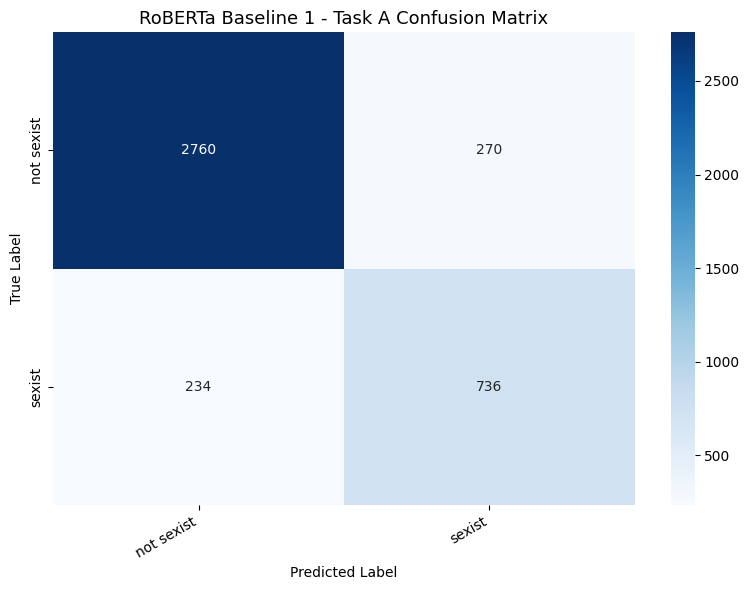

Accuracy:  0.874
Precision: 0.8267270126734583
Recall:    0.8348269878534245
Macro F1:  0.8306369663048212


In [7]:
trainer_a, test_a, id2label_a, num_labels_a = train_roberta(task='A')
results_a = evaluate_roberta(trainer_a, test_a, id2label_a, num_labels_a, task='A')


Training RoBERTa Baseline 1 — Task B
Task B : Train split (3398 posts)
1. threats, plans to harm and incitement        310 (9.1%)
2. derogation                                  1590 (46.8%)
3. animosity                                   1165 (34.3%)
4. prejudiced discussions                       333 (9.8%)
Task B : Dev split (486 posts)
1. threats, plans to harm and incitement         44 (9.1%)
2. derogation                                   227 (46.7%)
3. animosity                                    167 (34.4%)
4. prejudiced discussions                        48 (9.9%)
Task B : Test split (970 posts)
1. threats, plans to harm and incitement         89 (9.2%)
2. derogation                                   454 (46.8%)
3. animosity                                    333 (34.3%)
4. prejudiced discussions                        94 (9.7%)

Datasets ready — Train: 3398 | Dev: 486 | Test: 970
num_labels: 4
Class counts: [310.0, 1590.0, 1165.0, 333.0]
Class weights: [1.6722, 0.326, 0.445, 1

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4377.61it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be remo

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,1.022976,1.156748,0.450600,0.446500,0.506800,0.521700
2,0.849741,1.056625,0.609100,0.591000,0.628800,0.584200
3,0.654257,0.978595,0.615200,0.616000,0.596700,0.645500


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


Model saved to ../models/roberta_task_B

Evaluating on test set - Task B



Classification Report:
                                          precision    recall  f1-score   support

1. threats, plans to harm and incitement     0.6036    0.7528    0.6700        89
                           2. derogation     0.6629    0.6410    0.6517       454
                            3. animosity     0.5895    0.5045    0.5437       333
               4. prejudiced discussions     0.4741    0.6809    0.5590        94

                                accuracy                         0.6082       970
                               macro avg     0.5825    0.6448    0.6061       970
                            weighted avg     0.6139    0.6082    0.6073       970

Report saved to ../results/task_B_baseline1_results.txt


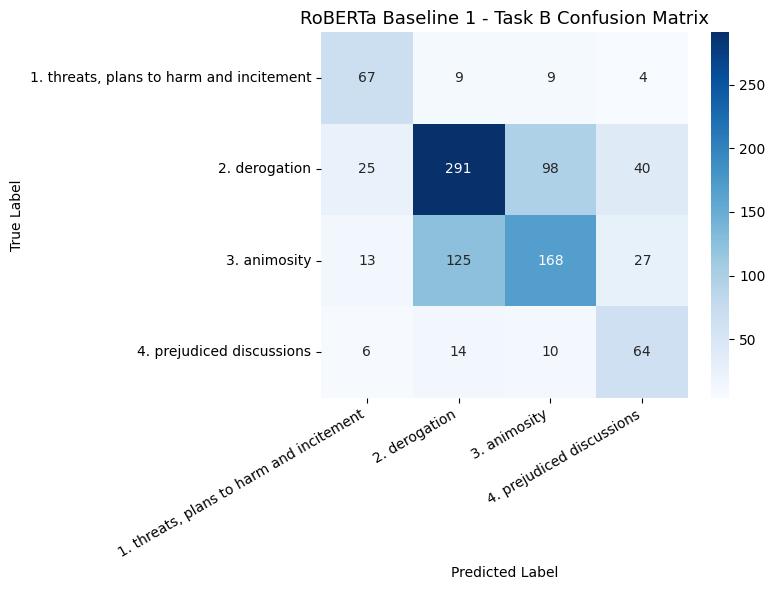

Accuracy:  0.6082474226804123
Precision: 0.5825053803353768
Recall:    0.6447834300234828
Macro F1:  0.6060942519345716


In [8]:
trainer_b, test_b, id2label_b, num_labels_b = train_roberta(task='B')
results_b = evaluate_roberta(trainer_b, test_b, id2label_b, num_labels_b, task='B')